## Exploration of Outputs from `src/extract.py`

Extract currently pulls tables from the [AACT mirror]((https://aact.ctti-clinicaltrials.org/)) of [ClinicalTrials.gov](https://www.clinicaltrials.gov), with filters in place that are intended to pull a "snapshot" of currently active or planned trials.  The goal in this notebook is to better understand the raw data, how to work with it, and any inconsistencies that could reflect issues with the early extract script logic.

## Exploration Objectives
- Extend `notebooks/01_raw_data_validation.ipynb` to confirm that raw data make sense
- Develop conceptual filtering strategies to get at subsets of industry-sponsored trials and possibly IITs sponsored by industry
  - Consider how to exclude non-interventional studies, studies of devices vs drugs, registries, & healthy volunteer studies
- Scope the size of key labeling problems: 
 1) Canoninical naming for sponsors
 2) Canoninical MeSH term mapping for Conditions
 3) Canonical naming for drugs interventions

> **Note** While data exploration is being performed in R for convenience, python will be used for ETL pipeline construction

In [51]:

library(tidyverse)
library(arrow)
library(tibble)
library(ggplot2)
library(dplyr)
library(janitor)
library(assertthat)
library(stringdist)
library(igraph)
library(reshape2)

STUDIES_DATA = '/Users/joshuaziel/Documents/coding/clinical-trials/data/raw/2026-03-21/studies.parquet'
SPONSORS_DATA = '/Users/joshuaziel/Documents/coding/clinical-trials/data/raw/2026-03-21/sponsors.parquet'

# Load & Inspect Raw 'Studies' Data

**Approach**: 
1) Load the raw data from parquet file 
2) Create a new feature that pulls the year from the first posting date (`study_first_posted_date`)
3) Plot a histogram of first posting years

**Expectations**:
1) Generally speaking the first posting date for studies that are in progress.  Late stage trials may take a number of years to complete, however, we can safely assume that the bulk may have been posted for the first time.  Note that we can inspect this more closely by `phase` and by `overall_status`. 
  - We would expect a much smaller backlog of early phase studies potentially because they should complete faster
  - Trials that have completed enrollment (overall_status == 'ACTIVE_NOT_RECRUITING) should generally be older than studies that haven't started enrolling yet
2) Evaluate the pattern of missing data to confirm that fields related to completion, available results etc are largely null (a trial in progress by definition should not have results in most cases, unless there is an interim analysis)

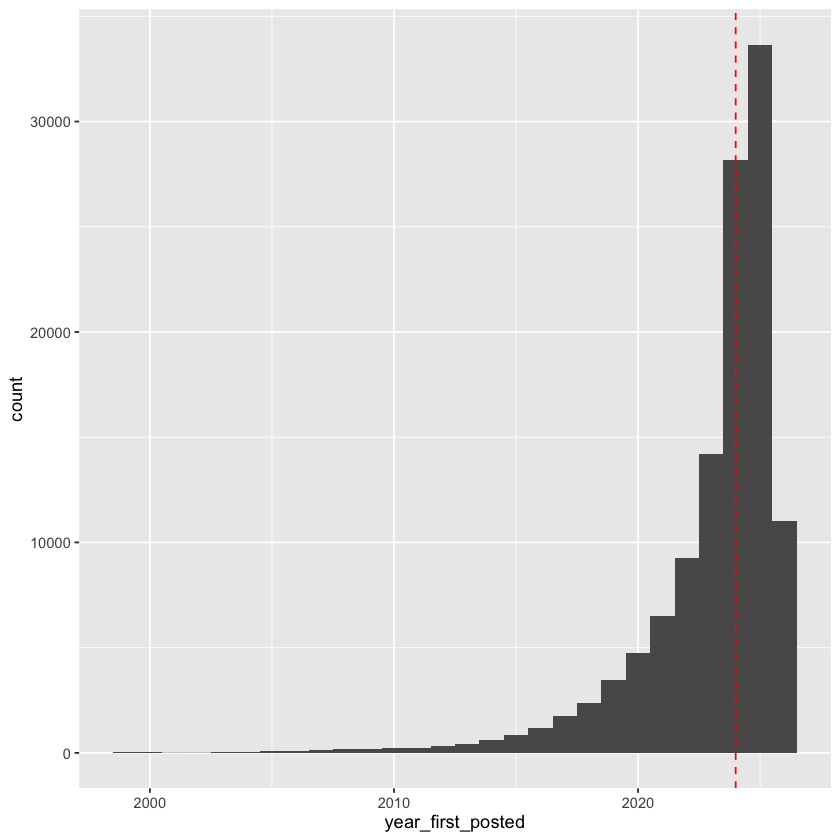

In [52]:
studies_data <- as_tibble(read_parquet(STUDIES_DATA)) |>
  mutate(year_first_posted = as.numeric(format(study_first_posted_date, '%Y'))) |>  # Adding a new feature to more easily explore the age of trials
  mutate(across(where(is.character), ~ replace(., . %in% c("NA", "none", "NaN", "N/A"), NA))) # Since we're loading in from parquet, we're going to try to fix any scenarios where 

ggplot(data = studies_data, aes(x=year_first_posted)) + 
  geom_histogram(binwidth = 1) +
  geom_vline(xintercept = median(studies_data$year_first_posted, na.rm = TRUE), # Adds a line for the median to the plot
    color = "red", linetype = "dashed")

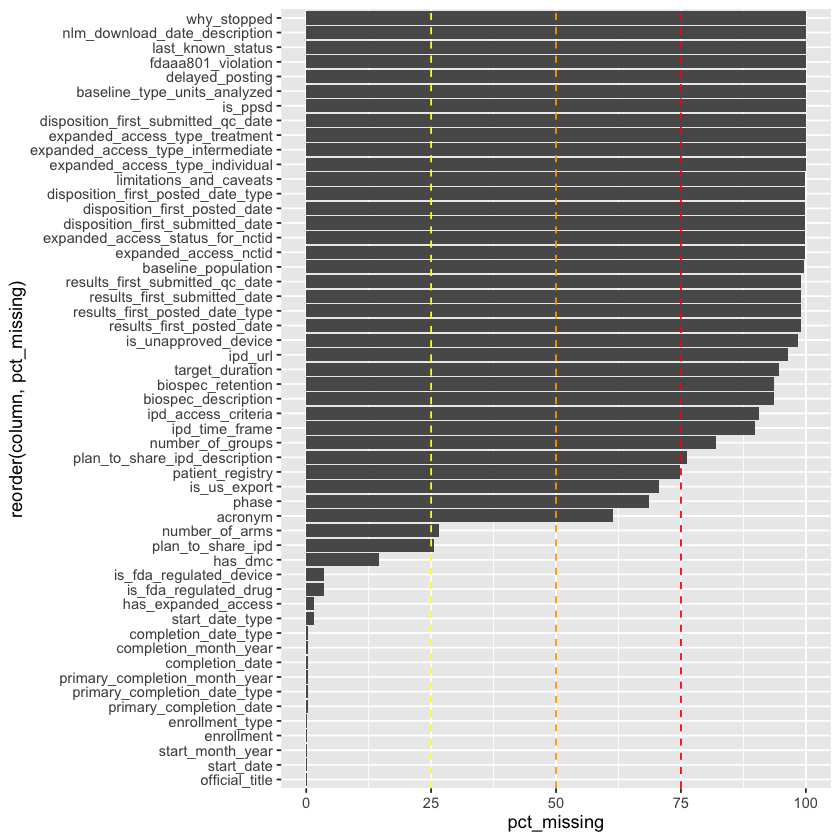

In [53]:
# Now let's see what's missing by getting missing values from the dataframe and plotting them as a percentage of all the data

missing_frame <- studies_data |>
  summarise(across(everything(), ~ sum(is.na(.)))) |>
  pivot_longer(everything(), names_to = "column", values_to = "missing_count") |> # This is important - summarise gives you a wide dataframe
  filter(missing_count > 0) |> # Only fields with missing data will be included
  mutate(
    pct_missing = missing_count / nrow(studies_data) * 100 # Add a new feature, which is the percentage of missting data
  ) |>
  arrange(desc(pct_missing))

ggplot(data = missing_frame, aes(x = pct_missing, y = reorder(column, pct_missing))) + # Note that reorder is important as the default is to plot in alpha order
  geom_col()+
  geom_vline(xintercept = 75, 
    color = "red", linetype = "dashed") +
  geom_vline(xintercept = 50, 
    color = "orange", linetype = "dashed") +
  geom_vline(xintercept = 25,
    color = "yellow", linetype = "dashed") 
  

In [54]:
# Each study can have multiple sponsors.  Here we're filtering to get a list of trial ids where an industry sponsor is the lead

industry_sponsored_ids <- as_tibble(read_parquet(SPONSORS_DATA)) |>
  filter(agency_class == 'INDUSTRY', lead_or_collaborator == 'lead') |> 
  pull(nct_id)

# My assumption is that there is only one lead sponsor - lets see if that's right
assert_that(
    length(industry_sponsored_ids) == length(unique(industry_sponsored_ids)),
    msg = "Warning - some industry sponsored trials have multiple lead sponsors"
)

[1] TRUE

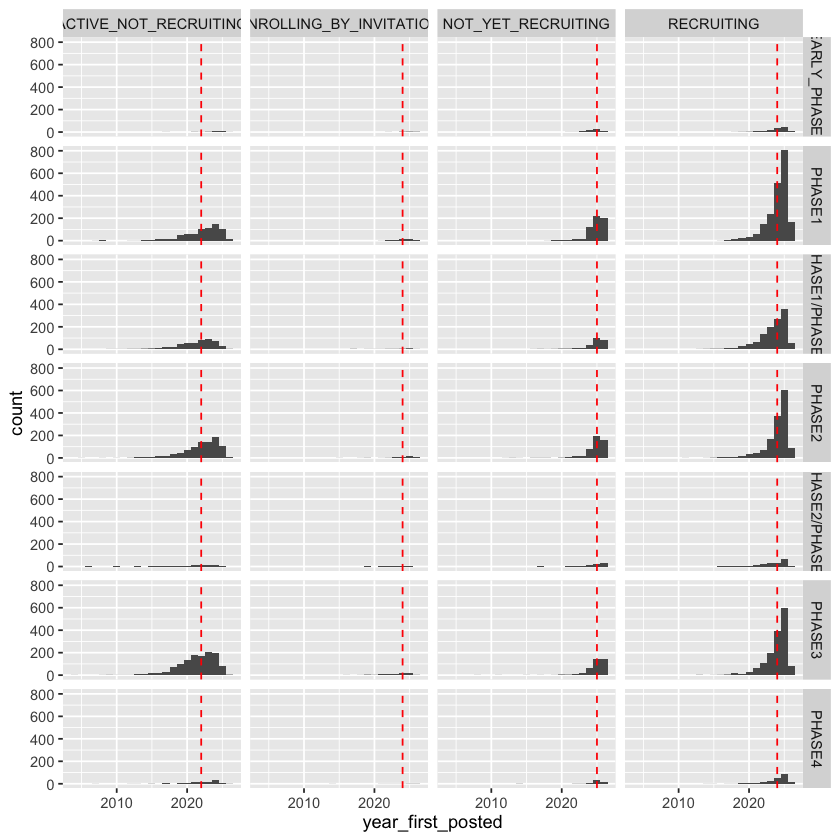

In [55]:
# Now let's filter out clearly defined patient registries, and places where the trial phase is NA
# Sidebar: there actually are more than a few studies with NA as the phase...might be worth looking into what they are

industry_sponsored_trials <- studies_data |>
  filter(nct_id %in% industry_sponsored_ids & (is.na(patient_registry) | !patient_registry) & !(is.na(phase)))

median_by_status <- industry_sponsored_trials |>
  group_by(overall_status) |>
  summarise(median_year = median(year_first_posted, na.rm = TRUE))

ggplot(data = industry_sponsored_trials, aes(x=year_first_posted)) + 
  geom_histogram(binwidth = 1) +
  facet_grid(phase ~ overall_status)+
  geom_vline(data = median_by_status, aes(xintercept = median_year),
    color = "red", linetype = "dashed")

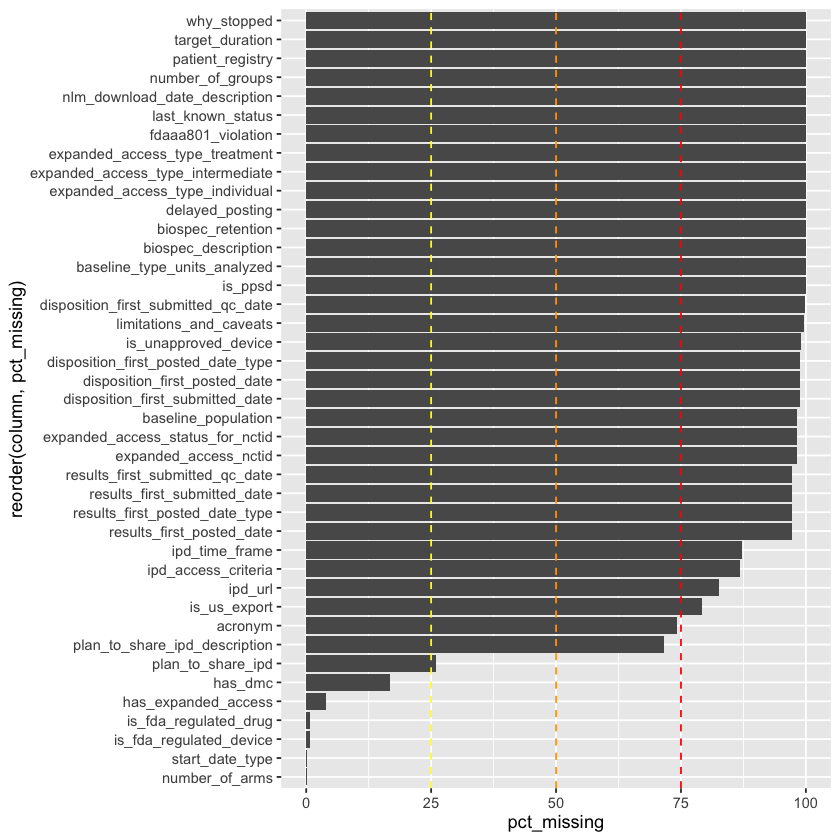

In [56]:
# Let's take a look at missing values should be broadly similar to the earlier look, however, industry sponsors might be more diligent in completing some fields up front

missing_frame <- industry_sponsored_trials |>
  summarise(across(everything(), ~ sum(is.na(.)))) |>
  pivot_longer(everything(), names_to = "column", values_to = "missing_count") |>
  filter(missing_count > 0) |>
  mutate(
    pct_missing = missing_count / nrow(industry_sponsored_trials) * 100
  ) |>
  arrange(desc(pct_missing))

ggplot(data = missing_frame, aes(x = pct_missing, y = reorder(column, pct_missing))) + 
  geom_col() + 
  geom_vline(xintercept = 75, 
    color = "red", linetype = "dashed") +
  geom_vline(xintercept = 50, 
    color = "orange", linetype = "dashed") +
  geom_vline(xintercept = 25, 
    color = "yellow", linetype = "dashed") 
  

In [57]:
sponsors_data = read_parquet(SPONSORS_DATA) |>
  filter(nct_id %in% industry_sponsored_ids) |>
  mutate(across(where(is.character), ~ replace(., . %in% c("NA", "none", "NaN", "N/A"), NA))) # Since we're loading in from parquet, we're going to try to fix any scenarios where 

if (sum(is.na(sponsors_data)) == 0) {
  message("No missing values detected in sponsors_data")
} else {
  missing_spons_frame <- sponsors_data |>
    summarise(across(everything(), ~ sum(is.na(.)))) |>
    pivot_longer(everything(), names_to = "column", values_to = "missing_count") |> # This is important - summarise gives you a wide dataframe
    filter(missing_count > 0) |> # Only fields with missing data will be included
    mutate(
      pct_missing = missing_count / nrow(sponsors_data) * 100 # Add a new feature, which is the percentage of missing data
    ) |>
    arrange(desc(pct_missing))

  ggplot(data = missing_spons_frame, aes(x = pct_missing, y = reorder(column, pct_missing))) + 
    geom_col() + 
    geom_vline(xintercept = 75, 
      color = "red", linetype = "dashed") +
    geom_vline(xintercept = 50, 
      color = "orange", linetype = "dashed") +
    geom_vline(xintercept = 25, 
      color = "yellow", linetype = "dashed") 
}

No missing values detected in sponsors_data



In [61]:
sponsors_data <- sponsors_data |>
  mutate(
    cln_name = name |>
      str_to_lower() |>
      str_remove_all("[[:punct:]]") |>
      str_remove_all("\\b(llc|inc|ltd|as|srl|plc|gmbh|corp|co|corporation|corp|group|and|company|pharmaceutical|pharmaceuticals|therapeutics)\\b") |>
      str_squish()
  )

raw_sponsor_rank <- sponsors_data |>
  select(nct_id, cln_name) |>
  distinct() |>
  count(cln_name, sort = TRUE)

head(raw_sponsor_rank)

cln_name,n
<chr>,<int>
astrazeneca,512
novartis,354
merck sharp dohme,353
abbvie,269
eli lilly,249
pfizer,248


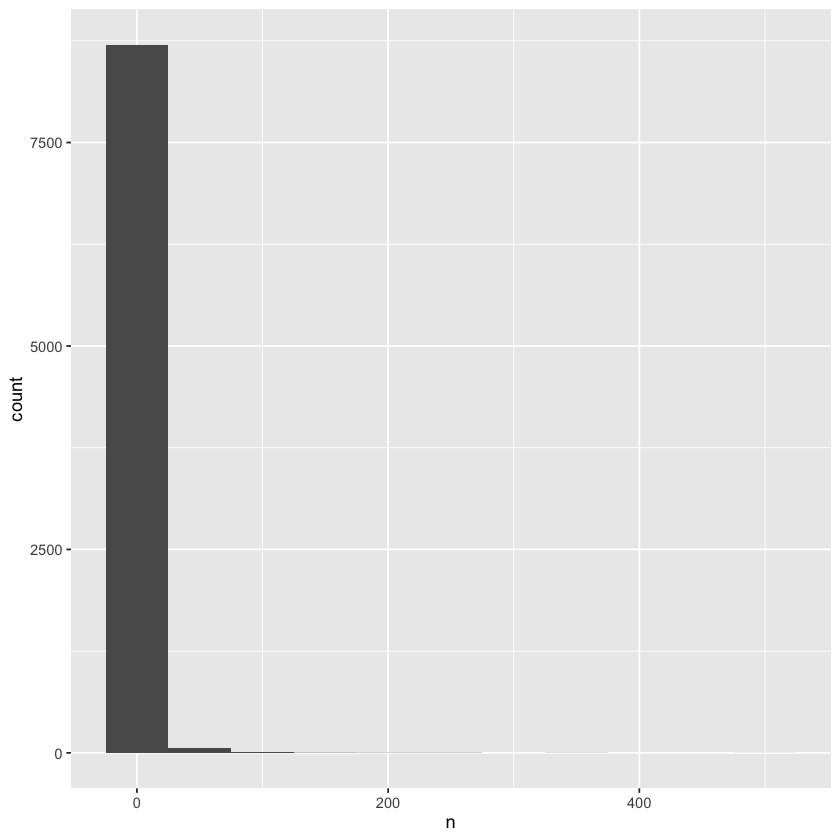

In [59]:
ggplot(data = raw_sponsor_rank, aes(x = n)) +
  geom_histogram(binwidth = 50)

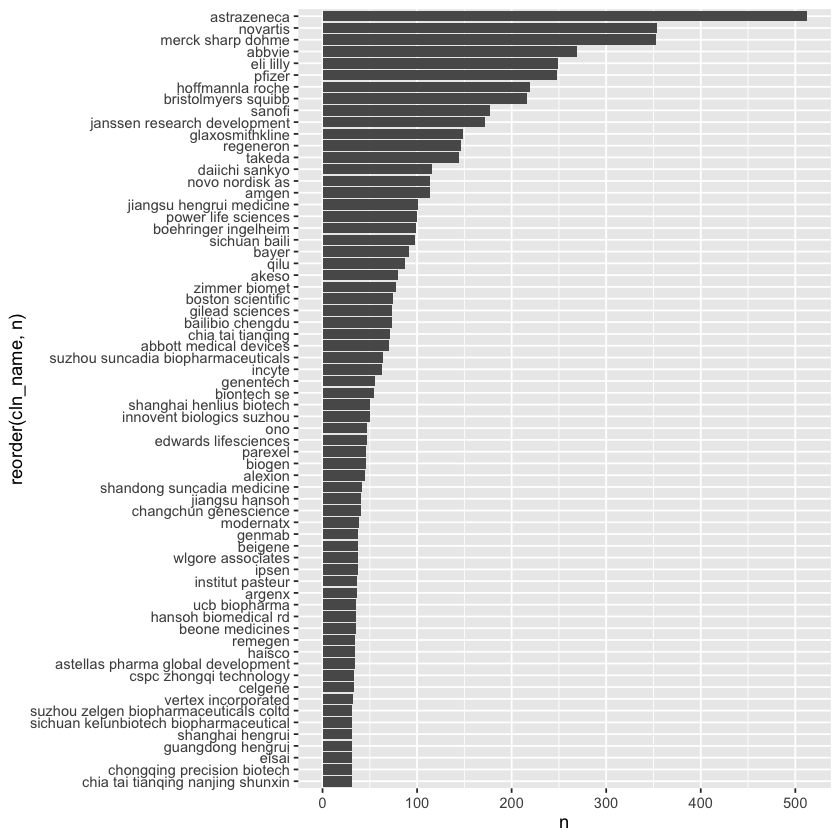

In [60]:
ggplot(data = filter(raw_sponsor_rank, n > 30), aes(x = n, y = reorder(cln_name, n))) +
  geom_col()